# Assignment 1 2AMM10 2025-2026

## Group: Working Title
### Member 1: Neha Bogavarapu
### Member 2: Sofie van Engelen (2224402)
### Member 3: Mees Peters (2085224)

## Task 1 

Dataset and visualization

Apple main varieties: 20


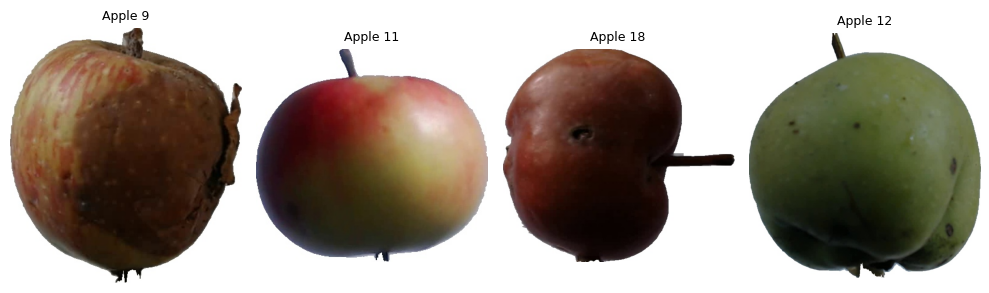

In [1]:

import os
import re
import math
import copy
import gc
from pathlib import Path
from collections import defaultdict, Counter

import kagglehub
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

DATASET_HANDLE = "moltean/fruits/versions/87"
SEED = 6
BATCH_SIZE = 32
IMAGE_SIZE = 64
EMBED_DIM = 128

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train", class_subset="main"):
        assert subset in ["train", "test"]
        assert class_subset in ["main", "new", "all"]
        path = kagglehub.dataset_download(DATASET_HANDLE)
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        self.path = base / ("Training" if subset == "train" else "Validation")
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator = np.random.default_rng(SEED)
        generator.shuffle(item_folders)
        if class_subset == "main":
            self.item_folders = item_folders[:20]
            label_offset = 0
        elif class_subset == "new":
            self.item_folders = item_folders[20:]
            label_offset = 20
        else:
            self.item_folders = item_folders
            label_offset = 0

        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0") and img_file.endswith(".jpg"):
                    self.targets.append(i + label_offset)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()
print(f"Apple main varieties: {len(dataset.item_folders)}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, folder in zip(axes, dataset.item_folders[:4]):
    frames = sorted(f for f in os.listdir(dataset.path / folder) if f.startswith("r0_") and f.endswith(".jpg"))
    img = Image.open(dataset.path / folder / frames[0])
    ax.imshow(img)
    ax.set_title(folder, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_data = AppleDataset(subset="train", transform=transform)
test_data = AppleDataset(subset="test", transform=transform)
support_new_data = AppleDataset(subset="train", transform=transform, class_subset="new")
test_new_data = AppleDataset(subset="test", transform=transform, class_subset="new")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
support_new_loader = DataLoader(support_new_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_new_loader = DataLoader(test_new_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Task 1 train images/classes: {len(train_data)} / {len(set(train_data.targets))}")
print(f"Task 1 test images/classes: {len(test_data)} / {len(set(test_data.targets))}")
print(f"Task 1 new support images/classes: {len(support_new_data)} / {len(set(support_new_data.targets))}")
print(f"Task 1 new test images/classes: {len(test_new_data)} / {len(set(test_new_data.targets))}")


2.5.1+cu121
cuda
NVIDIA GeForce RTX 3080
Task 1 train images/classes: 3068 / 20
Task 1 test images/classes: 1538 / 20
Task 1 new support images/classes: 1570 / 10
Task 1 new test images/classes: 781 / 10


Task 1 train: 3068 images, 20 labels


Task 1 test: 1538 images, 20 labels


Task 1 new support: 1570 images, 10 labels


Task 1 new test: 781 images, 10 labels


epoch 01/15 loss=0.0443


...

epoch 12/15 loss=0.0005


epoch 13/15 loss=0.0000


epoch 14/15 loss=0.0000


epoch 15/15 loss=0.0000


Seen item accuracy: 94.80%
Unseen item accuracy: 90.40%


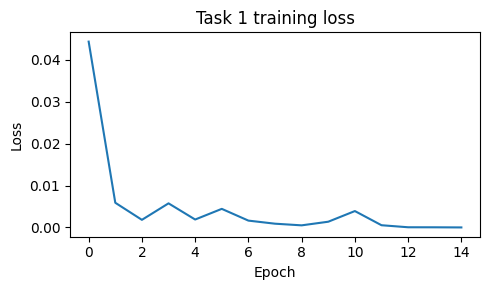

In [3]:

class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.embedding = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    distances = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1, 1)
    same_label = labels == labels.T
    different_label = labels != labels.T
    eye = torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)
    positive_mask = same_label & ~eye
    negative_mask = different_label
    hardest_positive = distances.masked_fill(~positive_mask, -1e9).max(dim=1).values
    hardest_negative = distances.masked_fill(~negative_mask, 1e9).min(dim=1).values
    valid_anchor = positive_mask.any(dim=1)
    if valid_anchor.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)
    loss = F.relu(hardest_positive - hardest_negative + margin)
    return loss[valid_anchor].mean()

def cache_labelled_dataset(dataset, name):
    images = torch.empty((len(dataset), 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.float32)
    labels = torch.empty(len(dataset), dtype=torch.long)
    for i in range(len(dataset)):
        image, label = dataset[i]
        images[i].copy_(image)
        labels[i] = int(label)
    print(f"{name}: {len(dataset)} images, {len(set(labels.tolist()))} labels")
    return images.to(device), labels.to(device)

def train_item_model(model, images, item_labels, epochs=15, family_labels=None, alpha=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    history = []
    n = len(images)
    n_batches = (n + BATCH_SIZE - 1) // BATCH_SIZE
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n, device=device)
        running_total = torch.zeros((), device=device)
        running_item = torch.zeros((), device=device)
        running_family = torch.zeros((), device=device)
        for start in range(0, n, BATCH_SIZE):
            idx = permutation[start:start + BATCH_SIZE]
            embeddings = model(images[idx])
            item_loss = batch_hard_triplet_loss(embeddings, item_labels[idx], margin=0.3)
            if family_labels is None:
                family_loss = torch.zeros((), device=device)
                loss = item_loss
            else:
                family_loss = batch_hard_triplet_loss(embeddings, family_labels[idx], margin=0.3)
                loss = item_loss + alpha * family_loss
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running_total += loss.detach()
            running_item += item_loss.detach()
            running_family += family_loss.detach()
        row = {
            "epoch": epoch + 1,
            "total_loss": (running_total / n_batches).item(),
            "item_loss": (running_item / n_batches).item(),
            "family_loss": (running_family / n_batches).item(),
        }
        history.append(row)
        print(f"epoch {epoch + 1:02d}/{epochs} loss={row['total_loss']:.4f}")
    return model, history

@torch.inference_mode()
def embed_tensor_images(model, images, batch_size=1024):
    model.eval()
    return torch.cat([model(images[i:i + batch_size]).detach() for i in range(0, len(images), batch_size)], dim=0)

@torch.inference_mode()
def nearest_neighbor_accuracy(model, support_images, support_labels, query_images, query_labels):
    support_emb = embed_tensor_images(model, support_images)
    query_emb = embed_tensor_images(model, query_images)
    predictions = []
    for start in range(0, len(query_emb), 1024):
        similarities = query_emb[start:start + 1024] @ support_emb.T
        predictions.append(support_labels[similarities.argmax(dim=1)].detach().cpu())
    predictions = torch.cat(predictions).to(query_labels.device)
    return (predictions == query_labels).float().mean().item()

set_seed()
task1_train_images, task1_train_labels = cache_labelled_dataset(train_data, "Task 1 train")
task1_test_images, task1_test_labels = cache_labelled_dataset(test_data, "Task 1 test")
task1_support_new_images, task1_support_new_labels = cache_labelled_dataset(support_new_data, "Task 1 new support")
task1_test_new_images, task1_test_new_labels = cache_labelled_dataset(test_new_data, "Task 1 new test")

model = EmbeddingCNN(embedding_dim=EMBED_DIM)
model, task1_history = train_item_model(model, task1_train_images, task1_train_labels, epochs=15)
seen_accuracy = nearest_neighbor_accuracy(model, task1_train_images, task1_train_labels, task1_test_images, task1_test_labels)
unseen_accuracy = nearest_neighbor_accuracy(model, task1_support_new_images, task1_support_new_labels, task1_test_new_images, task1_test_new_labels)

os.makedirs("saved_models", exist_ok=True)
torch.save(model.state_dict(), "saved_models/task1_embedding_model.pth")
print(f"Seen item accuracy: {seen_accuracy * 100:.2f}%")
print(f"Unseen item accuracy: {unseen_accuracy * 100:.2f}%")

plt.figure(figsize=(5, 3))
plt.plot([row["total_loss"] for row in task1_history])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1 training loss")
plt.tight_layout()
plt.show()


## Task 2

Garden main families/items: 15 / 69


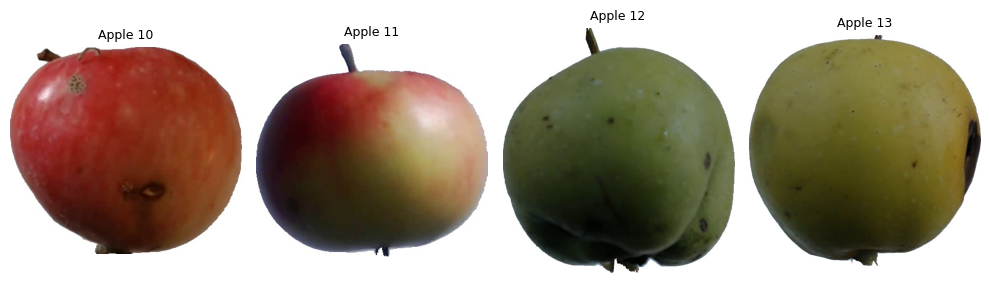

In [4]:

class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item", "family", "both"]
        assert subset in ["train", "test"]
        assert family_subset in ["main", "new", "all"]
        assert item_subset in ["main", "new", "all"]
        path = kagglehub.dataset_download(DATASET_HANDLE)
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        self.path = base / ("Training" if subset == "train" else "Validation")
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(d for d in os.listdir(base / "Training") if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d))
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))
        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0])

        present = {d for d in os.listdir(self.path) if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)}
        all_items = [it for it in canonical_items if it in present]
        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]
        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith(".jpg"):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
            return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()
print(f"Garden main families/items: {len(dataset.families)} / {len(dataset.items)}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, item in zip(axes, dataset.items[:4]):
    frames = sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))
    img = Image.open(dataset.path / item / frames[0])
    ax.imshow(img)
    ax.set_title(item, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:

train_data = GardenDataset(subset="train", transform=transform)
test_data = GardenDataset(subset="test", transform=transform)
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all", class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new", class_level="family")

assert len(train_data.families) == 15
assert len(set(train_data.targets_item)) == 69
assert len(test_new_data) > 0
assert len(test_new_data_family) > 0
support_paths = {str(path) for path in support_all_data.image_paths}
test_paths = {str(path) for path in test_new_data.image_paths} | {str(path) for path in test_new_data_family.image_paths}
assert support_paths.isdisjoint(test_paths)

print(f"Task 2 main train families/items: {len(train_data.families)} / {len(set(train_data.targets_item))}")
print(f"Scenario 1 test images: {len(test_data)}")
print(f"Scenario 3 new-item test images: {len(test_new_data)}")
print(f"Scenario 4 new-family test images: {len(test_new_data_family)}")


Task 2 main train families/items: 15 / 69
Scenario 1 test images: 13283
Scenario 3 new-item test images: 1737
Scenario 4 new-family test images: 2196


Garden train: cached 5000/34420


Garden train: cached 10000/34420


Garden train: cached 15000/34420


Garden train: cached 20000/34420


Garden train: cached 25000/34420


...

epoch 12/15 loss=0.0232


epoch 13/15 loss=0.0203


epoch 14/15 loss=0.0199


epoch 15/15 loss=0.0167


Task 2 results
scenario                     level      k   accuracy  n_test
scenario_1_items_main        Items      1    100.00%   13283
scenario_1_items_main        Items      3     99.99%   13283
scenario_1_items_main        Items      5     99.99%   13283
scenario_2_families_main     Families   1    100.00%   13283
scenario_2_families_main     Families   3    100.00%   13283
scenario_2_families_main     Families   5    100.00%   13283
scenario_3_new_items         Items      1    100.00%    1737
scenario_3_new_items         Items      3    100.00%    1737
scenario_3_new_items         Items      5    100.00%    1737
scenario_4_new_families      Families   1    100.00%    2196
scenario_4_new_families      Families   3    100.00%    2196
scenario_4_new_families      Families   5    100.00%    2196


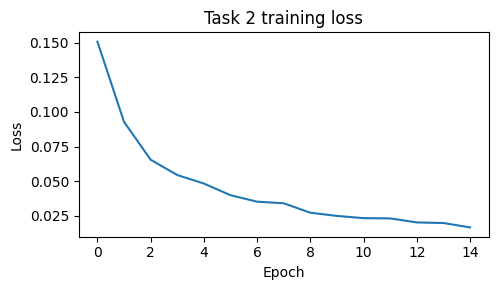

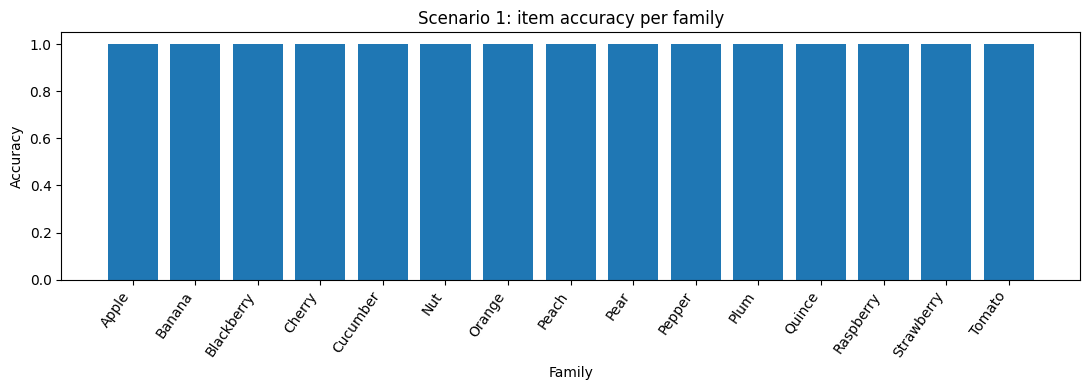

Lowest per-family item accuracy: 100.00%
Hardest family/families: Apple, Banana, Blackberry, Cherry, Cucumber, Nut, Orange, Peach, Pear, Pepper, Plum, Quince, Raspberry, Strawberry, Tomato


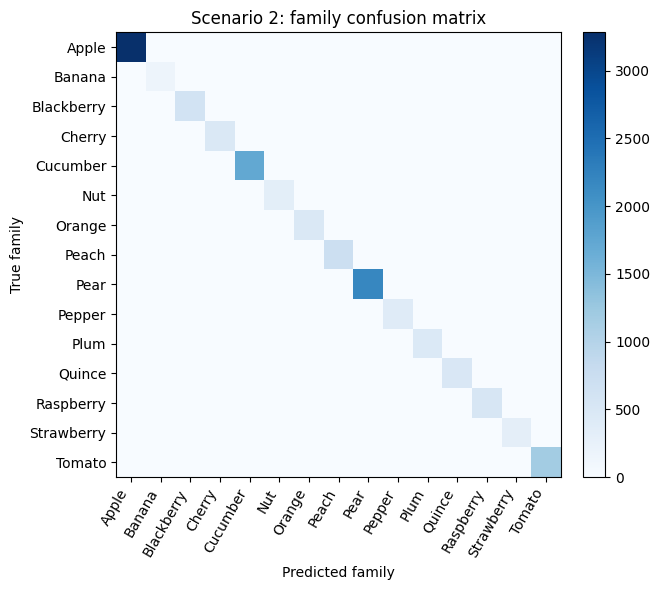

In [6]:

def cache_garden_dataset(dataset, name):
    n = len(dataset)
    images = torch.empty((n, 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.float32)
    family_labels = torch.empty(n, dtype=torch.long)
    item_labels = torch.empty(n, dtype=torch.long)
    item_names = []
    family_names = []
    for i in range(n):
        image, family_label, item_label = dataset[i]
        images[i].copy_(image)
        family_labels[i] = int(family_label)
        item_labels[i] = int(item_label)
        item_name = Path(dataset.image_paths[i]).parent.name
        item_names.append(item_name)
        family_names.append(dataset.item_to_family[item_name])
        if (i + 1) % 5000 == 0 or i + 1 == n:
            print(f"{name}: cached {i + 1}/{n}")
    return {
        "images": images.to(device),
        "family_labels": family_labels.to(device),
        "item_labels": item_labels.to(device),
        "item_names": item_names,
        "family_names": family_names,
        "paths": [str(path) for path in dataset.image_paths],
        "dataset": dataset,
    }

def garden_mask(cache, family_subset="main", item_subset="main"):
    new_families = set(cache["dataset"].new_families)
    new_items = set(cache["dataset"].new_items)
    mask = []
    for item_name, family_name in zip(cache["item_names"], cache["family_names"]):
        if family_subset == "main" and family_name in new_families:
            mask.append(False); continue
        if family_subset == "new" and family_name not in new_families:
            mask.append(False); continue
        if item_subset == "main" and item_name in new_items:
            mask.append(False); continue
        if item_subset == "new" and item_name not in new_items:
            mask.append(False); continue
        mask.append(True)
    return torch.tensor(mask, dtype=torch.bool)

def mask_indices(mask):
    return torch.nonzero(mask, as_tuple=False).flatten().to(device)

def majority_vote(neighbor_labels, k):
    if k == 1:
        return neighbor_labels[:, 0]
    predictions = []
    for row in neighbor_labels[:, :k]:
        values, counts = torch.unique(row, return_counts=True)
        predictions.append(values[counts.argmax()])
    return torch.stack(predictions)

@torch.inference_mode()
def knn_results(support_embeddings, support_labels, query_embeddings, query_labels, k_values=(1,)):
    max_k = max(k_values)
    support_labels = support_labels.to(support_embeddings.device)
    parts = []
    for start in range(0, len(query_embeddings), 1024):
        similarities = query_embeddings[start:start + 1024] @ support_embeddings.T
        indices = similarities.topk(max_k, largest=True).indices
        parts.append(support_labels[indices].detach().cpu())
    neighbor_labels = torch.cat(parts, dim=0)
    query_labels_cpu = query_labels.detach().cpu()
    output = {}
    for k in k_values:
        predictions = majority_vote(neighbor_labels, k)
        output[k] = {
            "accuracy": (predictions == query_labels_cpu).float().mean().item(),
            "predictions": predictions,
            "labels": query_labels_cpu,
        }
    return output

def evaluate_garden_model(eval_model, k_values=(1, 3, 5), keep_predictions=False):
    train_embeddings = embed_tensor_images(eval_model, garden_train_cache["images"])
    test_embeddings = embed_tensor_images(eval_model, garden_test_cache["images"])
    results = []
    predictions = {}
    for scenario in garden_scenarios:
        support_cache = garden_train_cache if scenario["support_source"] == "train" else garden_test_cache
        query_cache = garden_train_cache if scenario["test_source"] == "train" else garden_test_cache
        support_embeddings = train_embeddings if scenario["support_source"] == "train" else test_embeddings
        query_embeddings = train_embeddings if scenario["test_source"] == "train" else test_embeddings
        support_labels = support_cache[scenario["support_label_key"]][scenario["support_indices"]]
        query_labels = query_cache[scenario["test_label_key"]][scenario["test_indices"]]
        per_k = knn_results(
            support_embeddings[scenario["support_indices"]],
            support_labels,
            query_embeddings[scenario["test_indices"]],
            query_labels,
            k_values,
        )
        for k, values in per_k.items():
            results.append({
                "scenario": scenario["name"],
                "level": scenario["level"],
                "k": k,
                "accuracy": values["accuracy"],
                "n_test": int(scenario["test_indices"].numel()),
            })
            if keep_predictions:
                predictions[(scenario["name"], k)] = values
    del train_embeddings, test_embeddings
    torch.cuda.empty_cache()
    return results, predictions

def print_results_table(rows, title):
    print(title)
    print(f"{'scenario':<28} {'level':<9} {'k':>2} {'accuracy':>10} {'n_test':>7}")
    for row in rows:
        print(f"{row['scenario']:<28} {row['level']:<9} {row['k']:>2} {100 * row['accuracy']:>9.2f}% {row['n_test']:>7}")

set_seed()
garden_train_all = GardenDataset(class_level="both", transform=transform, subset="train", family_subset="all", item_subset="all")
garden_test_all = GardenDataset(class_level="both", transform=transform, subset="test", family_subset="all", item_subset="all")
garden_train_cache = cache_garden_dataset(garden_train_all, "Garden train")
garden_test_cache = cache_garden_dataset(garden_test_all, "Garden test")

garden_train_main_main = mask_indices(garden_mask(garden_train_cache, "main", "main"))
garden_train_main_all = mask_indices(garden_mask(garden_train_cache, "main", "all"))
garden_train_all_main = mask_indices(garden_mask(garden_train_cache, "all", "main"))
garden_test_main_main = mask_indices(garden_mask(garden_test_cache, "main", "main"))
garden_test_main_new = mask_indices(garden_mask(garden_test_cache, "main", "new"))
garden_test_new_main = mask_indices(garden_mask(garden_test_cache, "new", "main"))

main_items = {garden_train_cache["item_names"][i] for i in garden_train_main_main.detach().cpu().tolist()}
main_families = {garden_train_cache["family_names"][i] for i in garden_train_main_main.detach().cpu().tolist()}
assert len(main_families) == 15
assert len(main_items) == 69

garden_scenarios = [
    {"name": "scenario_1_items_main", "level": "Items", "support_source": "train", "support_indices": garden_train_main_main, "support_label_key": "item_labels", "test_source": "test", "test_indices": garden_test_main_main, "test_label_key": "item_labels"},
    {"name": "scenario_2_families_main", "level": "Families", "support_source": "train", "support_indices": garden_train_main_main, "support_label_key": "family_labels", "test_source": "test", "test_indices": garden_test_main_main, "test_label_key": "family_labels"},
    {"name": "scenario_3_new_items", "level": "Items", "support_source": "train", "support_indices": garden_train_main_all, "support_label_key": "item_labels", "test_source": "test", "test_indices": garden_test_main_new, "test_label_key": "item_labels"},
    {"name": "scenario_4_new_families", "level": "Families", "support_source": "train", "support_indices": garden_train_all_main, "support_label_key": "family_labels", "test_source": "test", "test_indices": garden_test_new_main, "test_label_key": "family_labels"},
]

task2_model = EmbeddingCNN(embedding_dim=EMBED_DIM)
task2_model, task2_history = train_item_model(
    task2_model,
    garden_train_cache["images"][garden_train_main_main],
    garden_train_cache["item_labels"][garden_train_main_main],
    epochs=15,
)
torch.save(task2_model.state_dict(), "saved_models/task2_embedding_model.pth")

task2_results, task2_predictions = evaluate_garden_model(task2_model, keep_predictions=True)
print_results_table(task2_results, "Task 2 results")

plt.figure(figsize=(5, 3))
plt.plot([row["item_loss"] for row in task2_history])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 2 training loss")
plt.tight_layout()
plt.show()

scenario1 = task2_predictions[("scenario_1_items_main", 1)]
idx_to_item = {idx: item for item, idx in garden_test_cache["dataset"].item_to_idx.items()}
family_rows = defaultdict(list)
for row_idx, label in enumerate(scenario1["labels"].tolist()):
    item_name = idx_to_item[int(label)]
    family_rows[garden_test_cache["dataset"].item_to_family[item_name]].append(row_idx)
per_family_rows = []
for family in sorted(family_rows):
    indices = torch.tensor(family_rows[family], dtype=torch.long)
    accuracy = (scenario1["predictions"][indices] == scenario1["labels"][indices]).float().mean().item()
    per_family_rows.append((family, accuracy, int(indices.numel())))

plt.figure(figsize=(11, 4))
plt.bar([row[0] for row in per_family_rows], [row[1] for row in per_family_rows])
plt.title("Scenario 1: item accuracy per family")
plt.xlabel("Family")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()
lowest_accuracy = min(row[1] for row in per_family_rows)
hardest_families = [row[0] for row in per_family_rows if np.isclose(row[1], lowest_accuracy)]
print(f"Lowest per-family item accuracy: {100 * lowest_accuracy:.2f}%")
print("Hardest family/families:", ", ".join(hardest_families))

scenario2 = task2_predictions[("scenario_2_families_main", 1)]
family_idx_to_name = {idx: family for family, idx in garden_test_cache["dataset"].family_to_idx.items()}
present_labels = sorted(set(scenario2["labels"].tolist()) | set(scenario2["predictions"].tolist()))
label_to_row = {label: i for i, label in enumerate(present_labels)}
matrix = np.zeros((len(present_labels), len(present_labels)), dtype=int)
for true_label, pred_label in zip(scenario2["labels"].tolist(), scenario2["predictions"].tolist()):
    matrix[label_to_row[true_label], label_to_row[pred_label]] += 1
names = [family_idx_to_name[label] for label in present_labels]
plt.figure(figsize=(7, 6))
plt.imshow(matrix, cmap="Blues")
plt.title("Scenario 2: family confusion matrix")
plt.xlabel("Predicted family")
plt.ylabel("True family")
plt.xticks(range(len(names)), names, rotation=60, ha="right")
plt.yticks(range(len(names)), names)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Task 3

In [7]:

train_data_both = GardenDataset(class_level="both", transform=transform, subset="train", family_subset="main", item_subset="main")
test_data_both = GardenDataset(class_level="both", transform=transform, subset="test", family_subset="main", item_subset="main")

TASK3_ALPHA = 0.25
TASK3_FINAL_K = 1
TASK3_EPOCHS = 15

def train_joint_embedding_model():
    set_seed()
    model = EmbeddingCNN(embedding_dim=EMBED_DIM)
    model, history = train_item_model(
        model,
        garden_train_cache["images"][garden_train_main_main],
        garden_train_cache["item_labels"][garden_train_main_main],
        epochs=TASK3_EPOCHS,
        family_labels=garden_train_cache["family_labels"][garden_train_main_main],
        alpha=TASK3_ALPHA,
    )
    return model, history

print(f"Task 3 train images: {len(train_data_both)}")
print(f"Task 3 fixed alpha: {TASK3_ALPHA}")
print("Task 3 loss: L_total = L_item + alpha * L_family")


Task 3 train images: 26559
Task 3 fixed alpha: 0.25
Task 3 loss: L_total = L_item + alpha * L_family


In [8]:

print(f"alpha={TASK3_ALPHA}")
task3_model, task3_history = train_joint_embedding_model()
task3_results, _ = evaluate_garden_model(task3_model, k_values=(TASK3_FINAL_K,))
for result in task3_results:
    result["alpha"] = TASK3_ALPHA
    result["epochs"] = TASK3_EPOCHS

task3_state_dict = {key: value.detach().cpu().clone() for key, value in task3_model.state_dict().items()}
task3_model.eval()
torch.save({
    "model_state_dict": task3_state_dict,
    "metadata": {"alpha": TASK3_ALPHA, "k": TASK3_FINAL_K, "epochs": TASK3_EPOCHS},
    "results": task3_results,
    "training_history": task3_history,
}, "saved_models/task3_joint_embedding_model.pth")

task2_reference = {result["scenario"]: result["accuracy"] for result in task2_results if result["k"] == TASK3_FINAL_K}
print_results_table(task3_results, "Final Task 3 fixed-alpha results")
print("Task 2 vs Task 3")
for result in task3_results:
    baseline = task2_reference[result["scenario"]]
    delta = result["accuracy"] - baseline
    print(f"{result['scenario']}: Task 2={100 * baseline:.2f}% Task 3={100 * result['accuracy']:.2f}% delta={100 * delta:+.2f} pp")


alpha=0.25


epoch 01/15 loss=0.2598


epoch 02/15 loss=0.1749


epoch 03/15 loss=0.1312


epoch 04/15 loss=0.1074


...

epoch 12/15 loss=0.0346


epoch 13/15 loss=0.0320


epoch 14/15 loss=0.0302


epoch 15/15 loss=0.0233


Final Task 3 fixed-alpha results
scenario                     level      k   accuracy  n_test
scenario_1_items_main        Items      1    100.00%   13283
scenario_2_families_main     Families   1    100.00%   13283
scenario_3_new_items         Items      1    100.00%    1737
scenario_4_new_families      Families   1    100.00%    2196
Task 2 vs Task 3
scenario_1_items_main: Task 2=100.00% Task 3=100.00% delta=+0.00 pp
scenario_2_families_main: Task 2=100.00% Task 3=100.00% delta=+0.00 pp
scenario_3_new_items: Task 2=100.00% Task 3=100.00% delta=+0.00 pp
scenario_4_new_families: Task 2=100.00% Task 3=100.00% delta=+0.00 pp


## Task 4

In [9]:

class BlackoutPixels:
    def __init__(self, fraction=0.1):
        assert 0.0 <= fraction <= 1.0
        self.fraction = float(fraction)

    def __call__(self, img):
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(round(num_pixels * self.fraction))
        if self.fraction > 0 and num_black == 0:
            num_black = 1
        corrupted = img.clone()
        if num_black == 0:
            return corrupted
        indices = torch.randperm(num_pixels, device=img.device)[:num_black]
        corrupted[:, indices // w, indices % w] = 0.0
        return corrupted

def corrupt_batch(images, fraction):
    blackout = BlackoutPixels(fraction)
    return torch.stack([blackout(image) for image in images])

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"), nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"), nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"), nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, kernel_size=3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

@torch.inference_mode()
def build_item_prototypes(model, train_images, train_item_labels):
    train_embeddings = embed_tensor_images(model, train_images)
    unique_labels = torch.unique(train_item_labels)
    prototypes = []
    for label in unique_labels:
        prototypes.append(train_embeddings[train_item_labels == label].mean(dim=0))
    prototypes = F.normalize(torch.stack(prototypes), p=2, dim=1)
    return prototypes, unique_labels

@torch.inference_mode()
def prototype_embedding_scores(model, prototypes, query_images):
    query_embeddings = embed_tensor_images(model, query_images)
    scores = []
    for start in range(0, len(query_embeddings), 1024):
        similarities = query_embeddings[start:start + 1024] @ prototypes.T
        scores.append((1.0 - similarities.max(dim=1).values).detach().cpu())
    return torch.cat(scores).numpy()

def quantile_threshold(clean_scores, quantile=0.90):
    threshold = float(np.quantile(clean_scores, quantile))
    false_positive_rate = float(np.mean(clean_scores > threshold))
    return threshold, false_positive_rate

def evaluate_embedding_detector(model, train_images, train_item_labels, test_images, corrupted_by_fraction):
    prototypes, _ = build_item_prototypes(model, train_images, train_item_labels)
    clean_scores = prototype_embedding_scores(model, prototypes, test_images)
    threshold, clean_fpr = quantile_threshold(clean_scores)
    detection_rates = {}
    for fraction, corrupted in corrupted_by_fraction.items():
        corrupted_scores = prototype_embedding_scores(model, prototypes, corrupted)
        detection_rates[fraction] = float(np.mean(corrupted_scores > threshold))
    return {"method": "Prototype embedding", "threshold": threshold, "clean_false_positive_rate": clean_fpr, "detection_rates": detection_rates}

def train_autoencoder(train_images, epochs=25):
    set_seed()
    model = ConvAutoencoder().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.L1Loss()
    history = []
    n = len(train_images)
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n, device=device)
        running = torch.zeros((), device=device)
        batches = 0
        for start in range(0, n, 64):
            idx = permutation[start:start + 64]
            clean = train_images[idx]
            reconstruction = model(clean)
            loss = loss_fn(reconstruction, clean)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running += loss.detach()
            batches += 1
        epoch_loss = (running / batches).item()
        history.append(epoch_loss)
        print(f"AE epoch {epoch + 1:02d}/{epochs} loss={epoch_loss:.5f}")
    return model, history

@torch.inference_mode()
def autoencoder_topk_scores(model, images, topk_fraction=0.01):
    model.eval()
    scores = []
    for start in range(0, len(images), 256):
        batch = images[start:start + 256]
        reconstruction = model(batch)
        residual = (reconstruction - batch).abs().mean(dim=1).flatten(start_dim=1)
        k = max(1, int(math.ceil(residual.shape[1] * topk_fraction)))
        scores.append(residual.topk(k, dim=1).values.mean(dim=1).detach().cpu())
    return torch.cat(scores).numpy()

def evaluate_autoencoder_detector(model, test_images, corrupted_by_fraction):
    clean_scores = autoencoder_topk_scores(model, test_images)
    threshold, clean_fpr = quantile_threshold(clean_scores)
    detection_rates = {}
    for fraction, corrupted in corrupted_by_fraction.items():
        corrupted_scores = autoencoder_topk_scores(model, corrupted)
        detection_rates[fraction] = float(np.mean(corrupted_scores > threshold))
    return {"method": "Autoencoder", "threshold": threshold, "clean_false_positive_rate": clean_fpr, "detection_rates": detection_rates}

print("Task 4 setup ready")


Task 4 setup ready


AE epoch 01/25 loss=0.06040


AE epoch 02/25 loss=0.02717


AE epoch 03/25 loss=0.02389


AE epoch 04/25 loss=0.02229


AE epoch 05/25 loss=0.02127


...

AE epoch 22/25 loss=0.01519


AE epoch 23/25 loss=0.01512


AE epoch 24/25 loss=0.01489


AE epoch 25/25 loss=0.01490


Task 4 anomaly detection results
method                    threshold  clean FPR       1%       5%      10%
Prototype embedding        0.028250     10.01%   91.40%  100.00%  100.00%
Autoencoder                0.220210     10.01%   99.92%  100.00%  100.00%


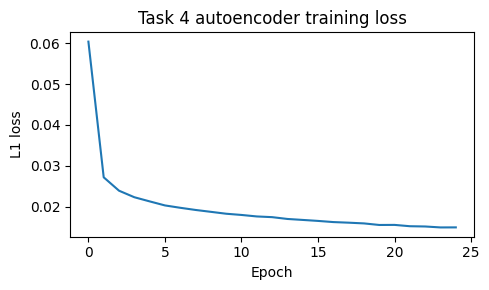

In [10]:

task4_train_images = garden_train_cache["images"][garden_train_main_main]
task4_train_item_labels = garden_train_cache["item_labels"][garden_train_main_main]
task4_test_images = garden_test_cache["images"][garden_test_main_main]
TASK4_FRACTIONS = [0.01, 0.05, 0.10]

set_seed(SEED)
corrupted_by_fraction = {fraction: corrupt_batch(task4_test_images, fraction) for fraction in TASK4_FRACTIONS}

task4_embedding_result = evaluate_embedding_detector(task3_model, task4_train_images, task4_train_item_labels, task4_test_images, corrupted_by_fraction)
task4_autoencoder, task4_autoencoder_history = train_autoencoder(task4_train_images, epochs=25)
task4_autoencoder_result = evaluate_autoencoder_detector(task4_autoencoder, task4_test_images, corrupted_by_fraction)
task4_results = [task4_embedding_result, task4_autoencoder_result]

print("Task 4 anomaly detection results")
print(f"{'method':<24} {'threshold':>10} {'clean FPR':>10} {'1%':>8} {'5%':>8} {'10%':>8}")
for result in task4_results:
    rates = result["detection_rates"]
    print(f"{result['method']:<24} {result['threshold']:>10.6f} {100 * result['clean_false_positive_rate']:>9.2f}% {100 * rates[0.01]:>7.2f}% {100 * rates[0.05]:>7.2f}% {100 * rates[0.10]:>7.2f}%")

plt.figure(figsize=(5, 3))
plt.plot(task4_autoencoder_history)
plt.xlabel("Epoch")
plt.ylabel("L1 loss")
plt.title("Task 4 autoencoder training loss")
plt.tight_layout()
plt.show()
